# Final Notebook: MFA vs SOFA — Phoneme Alignment Comparison

This notebook compares **two** alignment systems on three GT-Singer groups:
- **MFA Only** — Montreal Forced Aligner (speech-trained HMMs)
- **SOFA** — Singing-Oriented Forced Aligner (deep learning, singing-trained)

Singer groups: EN-Alto-1 · EN-Alto-2 · EN-Tenor-1

**Metrics**: Boundary MAE (ms), TBE@20ms, TBE@50ms, Interval IoU, Label Recall, Label Precision

## 1. Configuration

In [2]:
PROJECT_ROOT = Path(r"C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final Project")

SINGER_PATHS = {
    "EN-Alto-1":  Path(r"C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final Project\English\English\EN-Alto-1"),
    "EN-Alto-2":  Path(r"C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final Project\English\English\EN-Alto-2"),
    "EN-Tenor-1": Path(r"C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final Project\English\English\EN-Tenor-1"),
}

GT_ROOT        = PROJECT_ROOT / "English" / "English"
MFA_CORPUS     = PROJECT_ROOT / "MFA_Corpus"
MFA_OUTPUTS    = PROJECT_ROOT / "MFA_Outputs"
SOFA_DIR       = PROJECT_ROOT / "SOFA" / "segments"
SOFA_INDEX_CSV = PROJECT_ROOT / "Alignment_Eval" / "final_notebook" / "sofa_index.csv"

EVAL_DIR = PROJECT_ROOT / "Alignment_Eval" / "final_notebook"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

for singer, p in SINGER_PATHS.items():
    print(f"{singer}: {p}")
print("\nEvaluation output folder:", EVAL_DIR)


EN-Alto-1: C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final Project\English\English\EN-Alto-1
EN-Alto-2: C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final Project\English\English\EN-Alto-2
EN-Tenor-1: C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final Project\English\English\EN-Tenor-1

Evaluation output folder: C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final Project\Alignment_Eval\final_notebook


## 2. Helper Functions

In [ ]:
SILENCE_LABELS = {
    "", " ", "sp", "sil", "spn", "pau", "br", "breath", "ap", "<sp>", "<SP>", "SIL"
}

PHONE_TIER_CANDIDATES = [
    "phones", "phone", "phoneme", "phonemes", "segments", "segment", "phones_1"
]

WORD_TIER_CANDIDATES = [
    "words", "word", "lyrics", "lyric", "text"
]


def norm_label(value):
    if value is None:
        return ""
    return str(value).strip()


def canonical_stem(value: str) -> str:
    return norm_label(value).replace("__", "_").lower()


def is_silence(label: str) -> bool:
    return norm_label(label).lower() in {s.lower() for s in SILENCE_LABELS}


def safe_float(value):
    try:
        return float(value)
    except Exception:
        return np.nan


def find_tier_by_name(tg, candidates):
    target = [c.lower() for c in candidates]
    for tier in tg.tiers:
        if norm_label(getattr(tier, "name", "")).lower() in target:
            return tier
    return None


def flattened_gt_id_from_path(tg_path: Path, gt_root: Path = GT_ROOT):
    rel = tg_path.relative_to(gt_root)
    parts = list(rel.parts)
    parts[-1] = Path(parts[-1]).stem
    return "_".join(parts)


def parse_intervals_from_textgrid(tg_path, prefer_phone_tier=True, drop_silence=True):
    tg = TextGrid()
    tg.read(str(tg_path))

    tier = None
    if prefer_phone_tier:
        tier = find_tier_by_name(tg, PHONE_TIER_CANDIDATES)
    if tier is None:
        tier = find_tier_by_name(tg, WORD_TIER_CANDIDATES)
    if tier is None:
        if len(tg.tiers) == 0:
            return pd.DataFrame(columns=["label", "start", "end", "dur", "idx"])
        tier = tg.tiers[0]

    rows = []
    for idx, interval in enumerate(tier):
        label = norm_label(getattr(interval, "mark", ""))
        start = safe_float(getattr(interval, "minTime", np.nan))
        end = safe_float(getattr(interval, "maxTime", np.nan))
        if np.isnan(start) or np.isnan(end):
            continue
        if drop_silence and is_silence(label):
            continue
        rows.append({
            "label": label,
            "start": start,
            "end": end,
            "dur": end - start,
            "idx": idx,
        })
    return pd.DataFrame(rows)


def match_segments_by_overlap(ref_df, hyp_df, min_iou=0.1):
    """Match GT segments to hypothesis segments by maximum time overlap.
    Returns list of (ref_idx, hyp_idx) pairs. Each ref interval matched to best overlapping hyp."""
    pairs = []
    used_hyp = set()
    for ri in range(len(ref_df)):
        g = ref_df.iloc[ri]
        best_iou = min_iou
        best_j = -1
        for hi in range(len(hyp_df)):
            if hi in used_hyp:
                continue
            h = hyp_df.iloc[hi]
            iou = interval_iou(g["start"], g["end"], h["start"], h["end"])
            if not np.isnan(iou) and iou > best_iou:
                best_iou = iou
                best_j = hi
        if best_j >= 0:
            pairs.append((ri, best_j))
            used_hyp.add(best_j)
    return pairs


def match_segments_by_label_sequence(ref_df, hyp_df):
    """Wrapper: use overlap-based matching (works across phoneme set differences)."""
    return match_segments_by_overlap(ref_df, hyp_df)


def interval_iou(a_start, a_end, b_start, b_end):
    inter = max(0.0, min(a_end, b_end) - max(a_start, b_start))
    union = max(a_end, b_end) - min(a_start, b_start)
    if union <= 0:
        return np.nan
    return inter / union


def compare_alignment_against_gt(gt_df, hyp_df, system_name):
    base = {
        "system": system_name,
        "n_gt": len(gt_df),
        "n_hyp": len(hyp_df),
        "n_matched": 0,
        "label_recall": 0.0,
        "label_precision": 0.0,
        "start_mae_ms": np.nan,
        "end_mae_ms": np.nan,
        "boundary_mae_ms": np.nan,
        "dur_mae_ms": np.nan,
        "mean_iou": np.nan,
        "tbe_20ms": np.nan,
        "tbe_50ms": np.nan,
    }

    if len(gt_df) == 0 or len(hyp_df) == 0:
        return base, pd.DataFrame()

    pairs = match_segments_by_label_sequence(gt_df, hyp_df)
    if not pairs:
        return base, pd.DataFrame()

    rows = []
    for gt_idx, hyp_idx in pairs:
        g = gt_df.iloc[gt_idx]
        h = hyp_df.iloc[hyp_idx]
        start_err = abs(h["start"] - g["start"])
        end_err = abs(h["end"] - g["end"])
        dur_err = abs(h["dur"] - g["dur"])
        rows.append({
            "gt_idx": gt_idx,
            "hyp_idx": hyp_idx,
            "label": g["label"],
            "gt_start": g["start"],
            "gt_end": g["end"],
            "hyp_start": h["start"],
            "hyp_end": h["end"],
            "start_abs_err_ms": start_err * 1000,
            "end_abs_err_ms": end_err * 1000,
            "boundary_abs_err_ms": ((start_err + end_err) / 2) * 1000,
            "dur_abs_err_ms": dur_err * 1000,
            "iou": interval_iou(g["start"], g["end"], h["start"], h["end"]),
        })

    detail_df = pd.DataFrame(rows)
    summary = {
        **base,
        "n_matched": len(detail_df),
        "label_recall": len(detail_df) / len(gt_df) if len(gt_df) else np.nan,
        "label_precision": len(detail_df) / len(hyp_df) if len(hyp_df) else np.nan,
        "start_mae_ms": detail_df["start_abs_err_ms"].mean(),
        "end_mae_ms": detail_df["end_abs_err_ms"].mean(),
        "boundary_mae_ms": detail_df["boundary_abs_err_ms"].mean(),
        "dur_mae_ms": detail_df["dur_abs_err_ms"].mean(),
        "mean_iou": detail_df["iou"].mean(),
        "tbe_20ms": (detail_df["boundary_abs_err_ms"] > 20).mean(),
        "tbe_50ms": (detail_df["boundary_abs_err_ms"] > 50).mean(),
    }
    return summary, detail_df


def build_gt_index():
    rows = []
    for singer, root in SINGER_PATHS.items():
        for tg in sorted(root.rglob('*.TextGrid')):
            rel = tg.relative_to(GT_ROOT)
            parts = rel.parts
            rows.append({
                "singer": singer,
                "gt_textgrid": str(tg),
                "gt_relpath": str(rel),
                "style": parts[1] if len(parts) > 1 else None,
                "song": parts[2] if len(parts) > 2 else None,
                "group": parts[3] if len(parts) > 3 else None,
                "utt_id": tg.stem,
                "corpus_stem": flattened_gt_id_from_path(tg),
                "canonical_stem": canonical_stem(flattened_gt_id_from_path(tg)),
            })
    return pd.DataFrame(rows)


def build_corpus_index():
    wavs = {p.stem: p for p in MFA_CORPUS.rglob('*.wav')}
    labs = {p.stem: p for p in MFA_CORPUS.rglob('*.lab')}
    rows = []
    for stem in sorted(set(wavs) | set(labs)):
        rows.append({
            "corpus_stem": stem,
            "canonical_stem": canonical_stem(stem),
            "wav_path": str(wavs[stem]) if stem in wavs else None,
            "lab_path": str(labs[stem]) if stem in labs else None,
            "has_wav": stem in wavs,
            "has_lab": stem in labs,
        })
    return pd.DataFrame(rows)


def build_system_index(root: Path, system_label: str):
    rows = []
    for tg in sorted(root.rglob('*.TextGrid')):
        rows.append({
            "canonical_stem": canonical_stem(tg.stem),
            "relative_path": str(tg.relative_to(root)),
            system_label: str(tg),
        })
    if not rows:
        return pd.DataFrame(columns=["canonical_stem", system_label])
    df = pd.DataFrame(rows)
    return df.sort_values('relative_path').drop_duplicates('canonical_stem')[['canonical_stem', system_label]]


def evaluate_system(rows_df, system_col, system_name):
    summary_rows = []
    detail_rows = []
    use_df = rows_df[rows_df['gt_textgrid'].notna() & rows_df[system_col].notna()].copy()
    print(f"{system_name}: evaluating {len(use_df)} items")
    for _, row in use_df.iterrows():
        gt_df = parse_intervals_from_textgrid(row['gt_textgrid'])
        hyp_df = parse_intervals_from_textgrid(row[system_col])
        summary, detail = compare_alignment_against_gt(gt_df, hyp_df, system_name)
        summary.update({
            "singer": row['singer'],
            "style": row['style'],
            "song": row['song'],
            "group": row['group'],
            "utt_id": row['utt_id'],
            "corpus_stem": row['corpus_stem'],
            "gt_textgrid": row['gt_textgrid'],
            "hyp_textgrid": row[system_col],
        })
        summary_rows.append(summary)
        if len(detail):
            detail['system'] = system_name
            detail['singer'] = row['singer']
            detail['style'] = row['style']
            detail['song'] = row['song']
            detail['group'] = row['group']
            detail['utt_id'] = row['utt_id']
            detail['corpus_stem'] = row['corpus_stem']
            detail_rows.append(detail)
    summary_df = pd.DataFrame(summary_rows)
    detail_df = pd.concat(detail_rows, ignore_index=True) if detail_rows else pd.DataFrame()
    return summary_df, detail_df


def build_final_report(overall_df, singer_df):
    if overall_df.empty:
        return "No system outputs were found yet, so the comparison report is still empty."

    lines = []
    lines.append("# Final Report: Singer-Level Comparison")
    lines.append("")
    lines.append("## Overall system ranking")
    ordered = overall_df.sort_values('mean_boundary_mae_ms', ascending=True)
    for _, row in ordered.iterrows():
        lines.append(
            f"- {row['system']}: boundary MAE={row['mean_boundary_mae_ms']:.2f} ms, "
            f"IoU={row['mean_iou']:.4f}, recall={row['mean_label_recall']:.4f}, n={int(row['n_items'])}"
        )
    lines.append("")
    lines.append("## Singer-wise summary")
    if singer_df.empty:
        lines.append("- No singer-wise comparison is available yet.")
    else:
        for singer in singer_df['singer'].dropna().unique():
            lines.append(f"### {singer}")
            sub = singer_df[singer_df['singer'] == singer].sort_values('mean_boundary_mae_ms')
            for _, row in sub.iterrows():
                lines.append(
                    f"- {row['system']}: boundary MAE={row['mean_boundary_mae_ms']:.2f} ms, "
                    f"IoU={row['mean_iou']:.4f}, recall={row['mean_label_recall']:.4f}, n={int(row['n_items'])}"
                )
    return "\n".join(lines)


#SOFA index loader
def build_sofa_index(gt_index_df=None):
    """Load pre-computed SOFA MD5 index CSV (avoids heavy in-notebook computation).
    Falls back to empty DataFrame if CSV is missing.
    """
    if SOFA_INDEX_CSV.exists():
        df = pd.read_csv(SOFA_INDEX_CSV)
        print(f"SOFA index loaded from CSV: {len(df)} entries")
        return df
    print("WARNING: sofa_index.csv not found. Run apply_praat_to_sofa.py first.")
    return pd.DataFrame(columns=["canonical_stem", "sofa_textgrid"])


## 3. Build GT / Corpus / System Indices

In [4]:
gt_index     = build_gt_index()
corpus_index = build_corpus_index()

match_df = gt_index.merge(corpus_index, on='canonical_stem', how='left', suffixes=('', '_corpus'))

# MFA system index
match_df = match_df.merge(build_system_index(MFA_OUTPUTS, 'mfa_textgrid'), on='canonical_stem', how='left')

# SOFA: loaded from pre-computed CSV
sofa_index = build_sofa_index()
match_df   = match_df.merge(sofa_index, on='canonical_stem', how='left')

print('GT rows:             ', len(gt_index))
print('Matched corpus wavs: ', match_df['wav_path'].notna().sum())
print('MFA outputs found:   ', match_df['mfa_textgrid'].notna().sum())
print('SOFA outputs found:  ', match_df['sofa_textgrid'].notna().sum())

match_df.head()


SOFA index loaded from CSV: 741 entries
GT rows:              5209
Matched corpus wavs:  811
MFA outputs found:    768
SOFA outputs found:   579


,singer,gt_textgrid,gt_relpath,style,song,group,utt_id,corpus_stem,canonical_stem,corpus_stem_corpus,wav_path,lab_path,has_wav,has_lab,mfa_textgrid,sofa_textgrid
0,EN-Alto-1,C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final P...,EN-Alto-1\Breathy\all is found\Breathy_Group\0...,Breathy,all is found,Breathy_Group,0000,EN-Alto-1_Breathy_all is found_Breathy_Group_0000,en-alto-1_breathy_all is found_breathy_group_0000,EN-Alto-1__Breathy__all is found__Breathy_Grou...,C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final P...,None,True,False,C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final P...,NaN
1,EN-Alto-1,C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final P...,EN-Alto-1\Breathy\all is found\Breathy_Group\0...,Breathy,all is found,Breathy_Group,0001,EN-Alto-1_Breathy_all is found_Breathy_Group_0001,en-alto-1_breathy_all is found_breathy_group_0001,EN-Alto-1__Breathy__all is found__Breathy_Grou...,C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final P...,None,True,False,C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final P...,NaN
2,EN-Alto-1,C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final P...,EN-Alto-1\Breathy\all is found\Breathy_Group\0...,Breathy,all is found,Breathy_Group,0002,EN-Alto-1_Breathy_all is found_Breathy_Group_0002,en-alto-1_breathy_all is found_breathy_group_0002,EN-Alto-1__Breathy__all is found__Breathy_Grou...,C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final P...,None,True,False,C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final P...,NaN
3,EN-Alto-1,C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final P...,EN-Alto-1\Breathy\all is found\Breathy_Group\0...,Breathy,all is found,Breathy_Group,0003,EN-Alto-1_Breathy_all is found_Breathy_Group_0003,en-alto-1_breathy_all is found_breathy_group_0003,EN-Alto-1__Breathy__all is found__Breathy_Grou...,C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final P...,None,True,False,C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final P...,NaN
4,EN-Alto-1,C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final P...,EN-Alto-1\Breathy\all is found\Breathy_Group\0...,Breathy,all is found,Breathy_Group,0004,EN-Alto-1_Breathy_all is found_Breathy_Group_0004,en-alto-1_breathy_all is found_breathy_group_0004,EN-Alto-1__Breathy__all is found__Breathy_Grou...,C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final P...,None,True,False,C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final P...,NaN


## 4. Coverage By Singer

In [5]:
coverage = (
    match_df.groupby('singer', dropna=False)
    .agg(
        gt_items=('corpus_stem', 'count'),
        corpus_matches=('wav_path', lambda s: s.notna().sum()),
        mfa_only=('mfa_textgrid', lambda s: s.notna().sum()),
        sofa=('sofa_textgrid', lambda s: s.notna().sum()),
    )
    .reset_index()
)
coverage.to_csv(EVAL_DIR / 'coverage_by_singer.csv', index=False)
coverage


,singer,gt_items,corpus_matches,mfa_only,sofa
0,EN-Alto-1,1275,586,556,237
1,EN-Alto-2,1352,84,79,107
2,EN-Tenor-1,2676,141,133,235


## 5. Evaluate The Two Systems

In [6]:
mfa_summary,  mfa_detail  = evaluate_system(match_df, 'mfa_textgrid',  'MFA Only')
sofa_summary, sofa_detail = evaluate_system(match_df, 'sofa_textgrid', 'SOFA')

all_summary = pd.concat(
    [mfa_summary, sofa_summary],
    ignore_index=True,
)
all_summary.head()


MFA Only: evaluating 768 items


SOFA: evaluating 579 items


,system,n_gt,n_hyp,n_matched,label_recall,label_precision,start_mae_ms,end_mae_ms,boundary_mae_ms,dur_mae_ms,...,tbe_20ms,tbe_50ms,singer,style,song,group,utt_id,corpus_stem,gt_textgrid,hyp_textgrid
0,MFA Only,22,20,19,0.863636,0.950000,17.473684,94.842105,56.157895,100.631579,...,0.526316,0.105263,EN-Alto-1,Breathy,all is found,Breathy_Group,0000,EN-Alto-1_Breathy_all is found_Breathy_Group_0000,C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final P...,C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final P...
1,MFA Only,41,41,34,0.829268,0.829268,31.235294,79.941176,55.588235,105.588235,...,0.558824,0.264706,EN-Alto-1,Breathy,all is found,Breathy_Group,0001,EN-Alto-1_Breathy_all is found_Breathy_Group_0001,C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final P...,C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final P...
2,MFA Only,20,19,16,0.800000,0.842105,43.375000,95.625000,69.500000,127.000000,...,0.687500,0.437500,EN-Alto-1,Breathy,all is found,Breathy_Group,0002,EN-Alto-1_Breathy_all is found_Breathy_Group_0002,C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final P...,C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final P...
3,MFA Only,18,16,9,0.500000,0.562500,66.666667,238.000000,152.333333,272.222222,...,0.888889,0.666667,EN-Alto-1,Breathy,all is found,Breathy_Group,0003,EN-Alto-1_Breathy_all is found_Breathy_Group_0003,C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final P...,C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final P...
4,MFA Only,40,37,25,0.625000,0.675676,49.760000,83.000000,66.380000,92.200000,...,0.720000,0.400000,EN-Alto-1,Breathy,all is found,Breathy_Group,0004,EN-Alto-1_Breathy_all is found_Breathy_Group_0004,C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final P...,C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final P...


## 6. Final Comparison Tables

In [7]:
if all_summary.empty:
    overall_summary = pd.DataFrame(columns=[
        'system', 'n_items', 'mean_label_recall', 'mean_label_precision',
        'mean_start_mae_ms', 'mean_end_mae_ms', 'mean_boundary_mae_ms',
        'mean_dur_mae_ms', 'mean_iou', 'mean_tbe_20ms', 'mean_tbe_50ms'
    ])
    by_singer = pd.DataFrame(columns=['system', 'singer', 'n_items',
        'mean_boundary_mae_ms', 'mean_iou', 'mean_label_recall',
        'mean_tbe_20ms', 'mean_tbe_50ms'])
else:
    overall_summary = (
        all_summary.groupby('system', dropna=False)
        .agg(
            n_items=('corpus_stem', 'nunique'),
            mean_label_recall=('label_recall', 'mean'),
            mean_label_precision=('label_precision', 'mean'),
            mean_start_mae_ms=('start_mae_ms', 'mean'),
            mean_end_mae_ms=('end_mae_ms', 'mean'),
            mean_boundary_mae_ms=('boundary_mae_ms', 'mean'),
            mean_dur_mae_ms=('dur_mae_ms', 'mean'),
            mean_iou=('mean_iou', 'mean'),
            mean_tbe_20ms=('tbe_20ms', 'mean'),
            mean_tbe_50ms=('tbe_50ms', 'mean'),
        )
        .reset_index()
        .sort_values('mean_boundary_mae_ms')
    )

    by_singer = (
        all_summary.groupby(['system', 'singer'], dropna=False)
        .agg(
            n_items=('corpus_stem', 'nunique'),
            mean_boundary_mae_ms=('boundary_mae_ms', 'mean'),
            mean_iou=('mean_iou', 'mean'),
            mean_label_recall=('label_recall', 'mean'),
            mean_tbe_20ms=('tbe_20ms', 'mean'),
            mean_tbe_50ms=('tbe_50ms', 'mean'),
        )
        .reset_index()
        .sort_values(['singer', 'mean_boundary_mae_ms'])
    )

overall_summary.to_csv(EVAL_DIR / 'overall_system_summary.csv', index=False)
by_singer.to_csv(EVAL_DIR / 'system_by_singer_summary.csv', index=False)

print('Overall summary')
print(overall_summary.to_string())
print('\nSinger-level summary')
print(by_singer.to_string())


Overall summary
     system  n_items  mean_label_recall  mean_label_precision  mean_start_mae_ms  mean_end_mae_ms  mean_boundary_mae_ms  mean_dur_mae_ms  mean_iou  mean_tbe_20ms  mean_tbe_50ms
1      SOFA      485           0.736768              0.750550          31.176162        65.349497             48.262830        80.054914  0.636475       0.497491       0.251742
0  MFA Only      747           0.759780              0.810413          29.971998        68.610325             49.291161        87.138965  0.683239       0.400114       0.176368

Singer-level summary
     system      singer  n_items  mean_boundary_mae_ms  mean_iou  mean_label_recall  mean_tbe_20ms  mean_tbe_50ms
0  MFA Only   EN-Alto-1      535             48.326075  0.681143           0.755186       0.405627       0.176392
3      SOFA   EN-Alto-1      213             52.910222  0.628351           0.712893       0.520883       0.272671
1  MFA Only   EN-Alto-2       79             37.932499  0.702250           0.778457      

## 7. Pairwise Comparison Table

In [8]:
if all_summary.empty:
    pairwise = pd.DataFrame()
else:
    pairwise = (
        all_summary.pivot_table(
            index=['corpus_stem', 'singer', 'style', 'song', 'group', 'utt_id'],
            columns='system',
            values='boundary_mae_ms',
            aggfunc='mean'
        )
        .reset_index()
    )

    if {'MFA Only', 'SOFA'}.issubset(pairwise.columns):
        pairwise['gain_sofa_vs_mfa_ms'] = pairwise['MFA Only'] - pairwise['SOFA']

pairwise.to_csv(EVAL_DIR / 'pairwise_comparison.csv', index=False)
pairwise.head(20)


system,corpus_stem,singer,style,song,group,utt_id,MFA Only,SOFA,gain_sofa_vs_mfa_ms
0,EN-Alto-1_Breathy_all is found_Breathy_Group_0000,EN-Alto-1,Breathy,all is found,Breathy_Group,0000,56.157895,NaN,NaN
1,EN-Alto-1_Breathy_all is found_Breathy_Group_0001,EN-Alto-1,Breathy,all is found,Breathy_Group,0001,55.588235,NaN,NaN
2,EN-Alto-1_Breathy_all is found_Breathy_Group_0002,EN-Alto-1,Breathy,all is found,Breathy_Group,0002,69.500000,NaN,NaN
3,EN-Alto-1_Breathy_all is found_Breathy_Group_0003,EN-Alto-1,Breathy,all is found,Breathy_Group,0003,152.333333,NaN,NaN
4,EN-Alto-1_Breathy_all is found_Breathy_Group_0004,EN-Alto-1,Breathy,all is found,Breathy_Group,0004,66.380000,NaN,NaN
5,EN-Alto-1_Breathy_all is found_Breathy_Group_0005,EN-Alto-1,Breathy,all is found,Breathy_Group,0005,68.476190,NaN,NaN
6,EN-Alto-1_Breathy_all is found_Breathy_Group_0006,EN-Alto-1,Breathy,all is found,Breathy_Group,0006,51.187500,NaN,NaN
7,EN-Alto-1_Breathy_all is found_Breathy_Group_0007,EN-Alto-1,Breathy,all is found,Breathy_Group,0007,95.875000,NaN,NaN
8,EN-Alto-1_Breathy_all is found_Breathy_Group_0008,EN-Alto-1,Breathy,all is found,Breathy_Group,0008,64.000000,NaN,NaN
9,EN-Alto-1_Breathy_all is found_Breathy_Group_0009,EN-Alto-1,Breathy,all is found,Breathy_Group,0009,264.611111,NaN,NaN


## 8. Visualizations

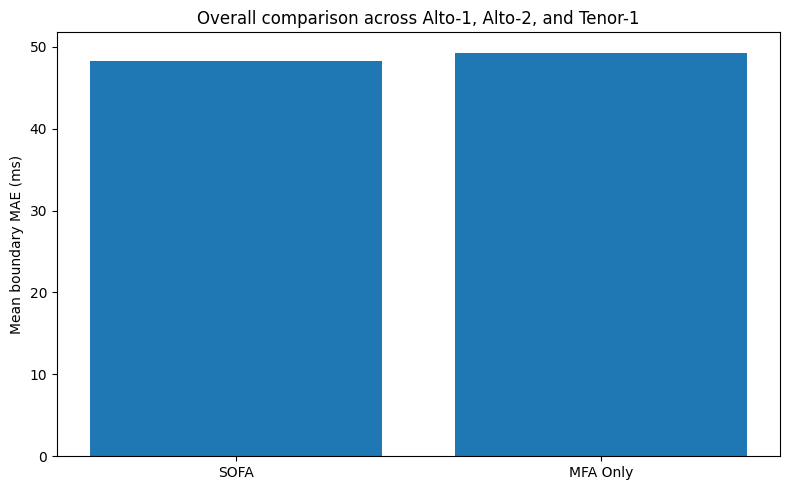

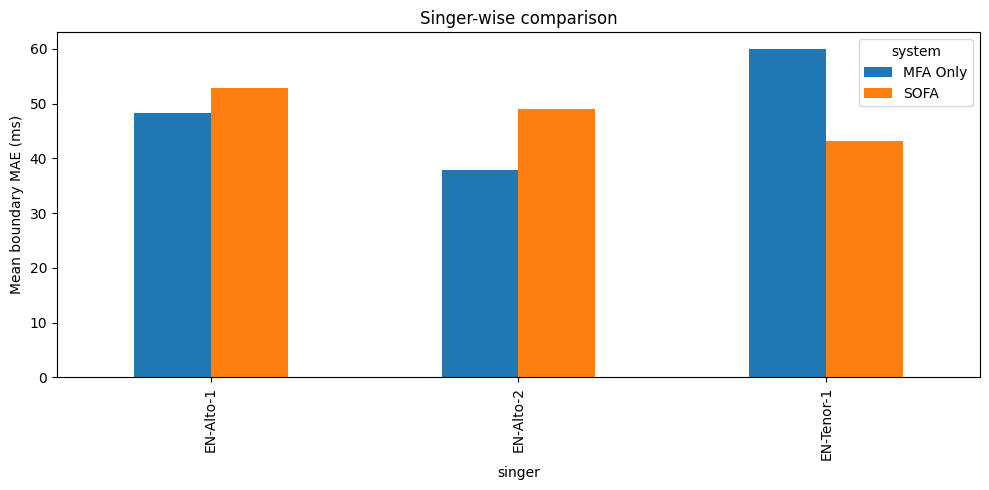

In [9]:
if not overall_summary.empty:
    plt.figure(figsize=(8, 5))
    plt.bar(overall_summary['system'], overall_summary['mean_boundary_mae_ms'])
    plt.ylabel('Mean boundary MAE (ms)')
    plt.title('Overall comparison across Alto-1, Alto-2, and Tenor-1')
    plt.tight_layout()
    plt.savefig(EVAL_DIR / 'overall_boundary_mae.png', dpi=200)
    plt.show()

if not by_singer.empty:
    pivot_plot = by_singer.pivot(index='singer', columns='system', values='mean_boundary_mae_ms')
    pivot_plot.plot(kind='bar', figsize=(10, 5))
    plt.ylabel('Mean boundary MAE (ms)')
    plt.title('Singer-wise comparison')
    plt.tight_layout()
    plt.savefig(EVAL_DIR / 'boundary_mae_by_singer.png', dpi=200)
    plt.show()


## 9. Final Report

In [10]:
final_report_text = build_final_report(overall_summary, by_singer)
report_path = EVAL_DIR / 'final_report.md'
report_path.write_text(final_report_text, encoding='utf-8')
print(final_report_text)
print('\nSaved to:', report_path)


# Final Report: Singer-Level Comparison

## Overall system ranking
- SOFA: boundary MAE=48.26 ms, IoU=0.6365, recall=0.7368, n=485
- MFA Only: boundary MAE=49.29 ms, IoU=0.6832, recall=0.7598, n=747

## Singer-wise summary
### EN-Alto-1
- MFA Only: boundary MAE=48.33 ms, IoU=0.6811, recall=0.7552, n=535
- SOFA: boundary MAE=52.91 ms, IoU=0.6284, recall=0.7129, n=213
### EN-Alto-2
- MFA Only: boundary MAE=37.93 ms, IoU=0.7022, recall=0.7785, n=79
- SOFA: boundary MAE=49.03 ms, IoU=0.6291, recall=0.7327, n=81
### EN-Tenor-1
- SOFA: boundary MAE=43.23 ms, IoU=0.6480, recall=0.7627, n=191
- MFA Only: boundary MAE=60.03 ms, IoU=0.6806, recall=0.7679, n=133

Saved to: C:\Users\rj_he\Desktop\UPF\Courses\MIR\Final Project\Alignment_Eval\final_notebook\final_report.md
